In [2]:
import pyarrow.parquet as pq
import pandas as pd
import os
import matplotlib.pyplot as plt

In [10]:
path = os.path.join('datas', 'ebnerd_demo','train', 'behaviors.parquet')
#print(path)
behaviors = pq.read_table(path).to_pandas()

behaviors_grouped = behaviors.groupby('user_id').first().reset_index()
behaviors_grouped.loc[:,'age'].isna().sum()/len(behaviors_grouped)

0.9823899371069182

In [3]:
path = os.path.join('datas', 'ebnerd_demo','train', 'history.parquet')
#print(path)
history = pq.read_table(path).to_pandas()
history
#legs.describe()


,user_id,impression_time_fixed,scroll_percentage_fixed,article_id_fixed,read_time_fixed
0,13538,"[2023-04-27T10:17:43.000000, 2023-04-27T10:18:...","[100.0, 35.0, 100.0, 24.0, 100.0, 23.0, 100.0,...","[9738663, 9738569, 9738663, 9738490, 9738663, ...","[17.0, 12.0, 4.0, 5.0, 4.0, 9.0, 5.0, 46.0, 11..."
1,58608,"[2023-04-27T18:48:09.000000, 2023-04-27T18:48:...","[37.0, 61.0, 100.0, 100.0, 55.0, 100.0, 100.0,...","[9739362, 9739179, 9738567, 9739344, 9739202, ...","[2.0, 24.0, 72.0, 65.0, 11.0, 4.0, 101.0, 0.0,..."
2,95507,"[2023-04-27T15:20:28.000000, 2023-04-27T15:20:...","[60.0, 100.0, 100.0, 21.0, 29.0, 67.0, 49.0, 5...","[9739035, 9738646, 9634967, 9738902, 9735495, ...","[18.0, 29.0, 51.0, 12.0, 10.0, 10.0, 13.0, 24...."
3,106588,"[2023-04-27T08:29:09.000000, 2023-04-27T08:29:...","[24.0, 57.0, 100.0, nan, nan, 100.0, 100.0, 73...","[9738292, 9738216, 9737266, 9737556, 9737657, ...","[9.0, 15.0, 42.0, 9.0, 3.0, 58.0, 26.0, 214.0,..."
4,617963,"[2023-04-27T14:42:25.000000, 2023-04-27T14:43:...","[100.0, 100.0, nan, 46.0, 23.0, 19.0, 61.0, 70...","[9739035, 9739088, 9738902, 9738968, 9738760, ...","[45.0, 29.0, 116.0, 26.0, 34.0, 42.0, 58.0, 59..."
...,...,...,...,...,...
1585,1122370,"[2023-05-09T06:50:19.000000, 2023-05-09T06:51:...","[100.0, 100.0, 100.0, 100.0, nan]","[9755181, 9706958, 9709329, 9706958, 9755571]","[84.0, 115.0, 298.0, 5.0, 79.0]"
1586,1718049,"[2023-05-17T05:04:36.000000, 2023-05-17T05:04:...","[53.0, 100.0, 24.0, 100.0, 83.0, 28.0, 37.0, 4...","[9768583, 9728166, 9768829, 9769641, 9769994, ...","[13.0, 17.0, 7.0, 99.0, 5.0, 8.0, 4.0, 2.0, 4.0]"
1587,1178033,"[2023-04-29T19:36:47.000000, 2023-04-29T19:37:...","[nan, 98.0, 92.0, 30.0, 35.0, 9.0, 34.0, 58.0,...","[9742268, 9742423, 9742270, 9742440, 9742459, ...","[10.0, 74.0, 89.0, 10.0, 1.0, 4.0, 11.0, 7.0, ..."
1588,395912,"[2023-05-12T05:12:34.000000, 2023-05-12T05:12:...","[100.0, 100.0, 100.0, 33.0, nan]","[9760741, 9760998, 9760935, 9754442, 9760935]","[16.0, 22.0, 23.0, 9.0, 0.0]"


In [5]:
path = os.path.join('datas', 'ebnerd_demo', 'articles.parquet')
#print(path)
articles = pq.read_table(path).to_pandas()
articles.isna().sum()/len(articles)
len(articles.loc[:,'article_id'].unique())
#legs.describe()

11777

In [6]:
len(behaviors.loc[:,'article_id'].unique())

923

# Data analysis of the articles.parquet file

### Import

In [4]:
path = os.path.join('datas', 'ebnerd_demo', 'articles.parquet')
print(path)
articles = pq.read_table(path).to_pandas()

datas/ebnerd_demo/articles.parquet


### NaN analysis
NaN ratio for every variables :

In [12]:
articles.isna().sum()/len(articles)

article_id            0.000000
title                 0.000000
subtitle              0.000000
last_modified_time    0.000000
premium               0.000000
body                  0.000000
published_time        0.000000
image_ids             0.079562
article_type          0.000000
url                   0.000000
ner_clusters          0.000000
entity_groups         0.000000
topics                0.000000
category              0.000000
subcategory           0.000000
category_str          0.000000
total_inviews         0.362656
total_pageviews       0.362656
total_read_time       0.362656
sentiment_score       0.000000
sentiment_label       0.000000
dtype: float64

We see a big proportion of NaN for total_inviews, total_pageviews and total_read_time, this can be explained mostly because "This feature only applies to articles that were published after February 16, 2023.".
This is mostly verified :

In [41]:
published_time_no_total = articles.loc[
    articles[['total_inviews', 'total_pageviews', 'total_read_time']].isna().any(axis=1), 
    'published_time'
]

published_time_no_total[published_time_no_total < '2023-02-16'].count()/len(published_time_no_total)

0.9957934096751577

In [19]:
articles.loc[:,['total_inviews','total_pageviews','total_read_time']].isna().any(axis=1).sum()

4279

Let's learn more about the totals : 

In [42]:
articles.loc[:,'total_inviews'].isna().sum()

4271

<Axes: >

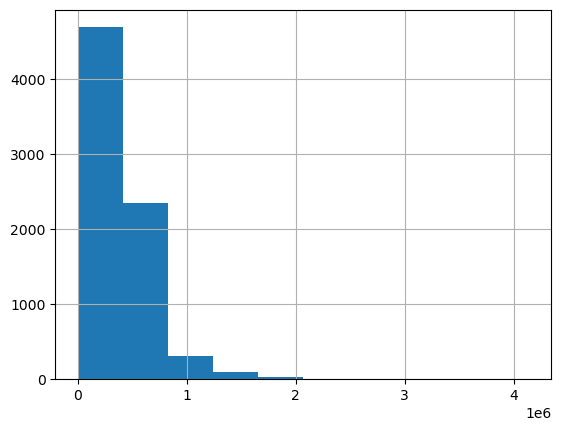

In [5]:
total_inviews_df = articles.loc[:,'total_inviews'].dropna()
total_inviews_df.hist()

In [43]:
articles.loc[:,'total_pageviews'].isna().sum()

4271